In [21]:
import numpy as np 
import pandas as pd 
from collections import defaultdict
 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [27]:
df_v2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\ufc_new_rolling.csv')
# df_v2 = df_v2.sort_values('date').reset_index(drop=True)
# df_v2 = df_v2[df_v2['winner']!=2].reset_index(drop=True)
# df_v2 = df_v2.dropna().reset_index(drop=True)

C:\Users\jcmar\AppData\Local\Temp\ipykernel_27516\79455400.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  return 1.0 / s
C:\Users\jcmar\AppData\Local\Temp\ipykernel_27516\79455400.py:49: RuntimeWarning: invalid value encountered in scalar multiply
  return v * s


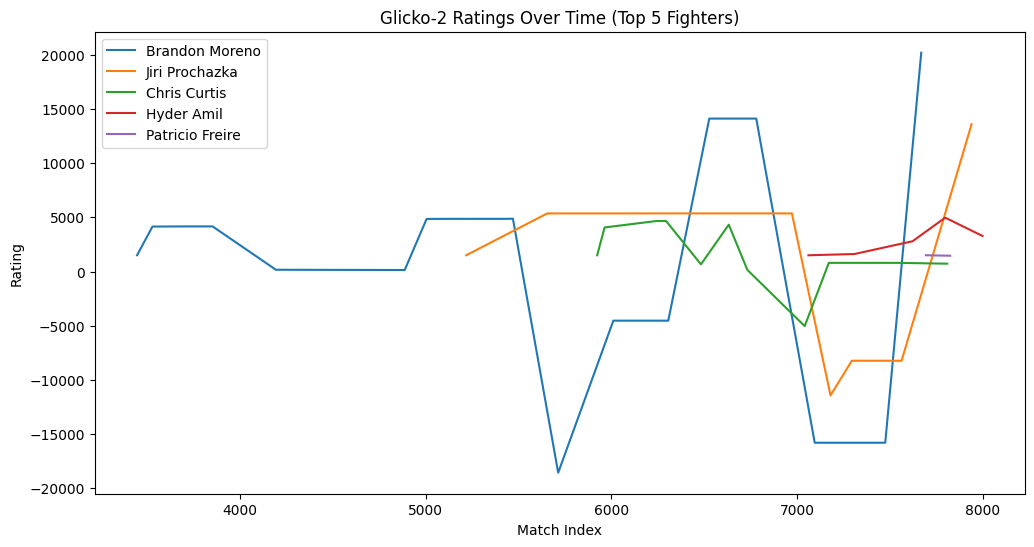

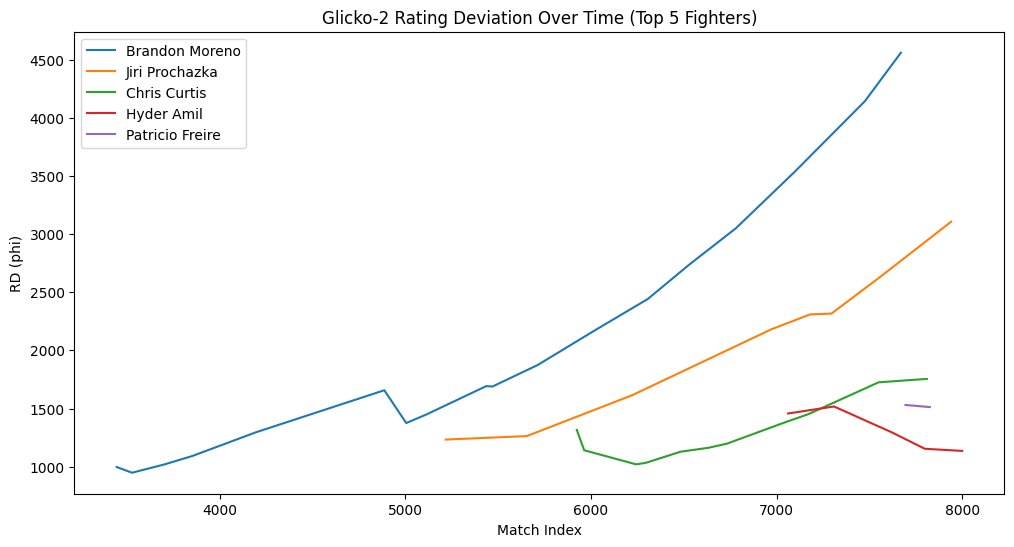

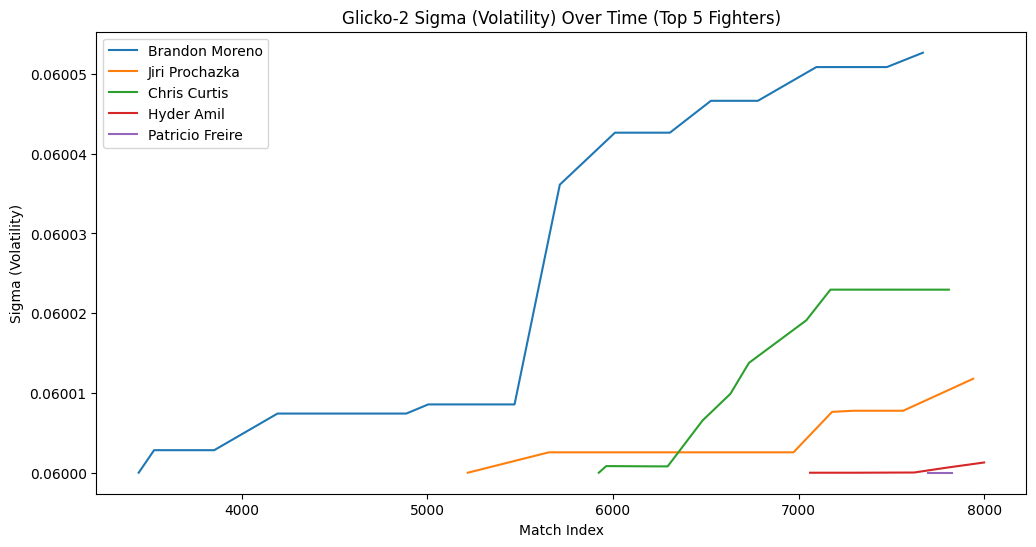

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, exp, sqrt, pi

# -------------------------
# Glicko-2 utility functions
# -------------------------
      # system constant (0.3 - 1.2). tweakable
EPSILON = 1e-6   # convergence tolerance

# g(phi) as in Glicko-2
def g(phi):
    return 1.0 / np.sqrt(1.0 + 3.0 * phi**2 / (pi**2))

# E(mu, mu_j, phi_j)
def E(mu, mu_j, phi_j):
    return 1.0 / (1.0 + np.exp(-g(phi_j) * (mu - mu_j)))

# scaling helpers (Glicko-2 scales)
Q = log(10) / 400.0  # sometimes used; we'll keep scale conversion functions

def scale_down(rating):
    """Convert rating R to Glicko-2 scale mu."""
    return (rating - 1500.0) / 173.7178

def scale_up(mu):
    """Convert mu back to rating scale R."""
    return mu * 173.7178 + 1500.0

# -------------------------
# Core Glicko-2 calculations
# -------------------------
def compute_v(mu, opponents_mu, opponents_phi):
    """Compute the estimated variance v."""
    s = 0.0
    for mu_j, phi_j in zip(opponents_mu, opponents_phi):
        e = E(mu, mu_j, phi_j)
        s += (g(phi_j)**2) * e * (1.0 - e)
    return 1.0 / s

def compute_delta(mu, opponents_mu, opponents_phi, outcomes):
    """Compute delta (the estimated improvement)."""
    v = compute_v(mu, opponents_mu, opponents_phi)
    s = 0.0
    for mu_j, phi_j, outcome in zip(opponents_mu, opponents_phi, outcomes):
        e = E(mu, mu_j, phi_j)
        s += g(phi_j) * (outcome - e)
    return v * s

def _f(x, delta, phi, v, a):
    """Function f used in sigma iterative search (Glickman)."""
    ex = np.exp(x)
    num = ex * (delta**2 - phi**2 - v - ex)
    den = 2.0 * (phi**2 + v + ex)**2
    return num / den - (x - a) / (TAU**2)

def update_sigma(mu, phi, sigma, opponents_mu, opponents_phi, outcomes):
    """
    Update volatility (sigma) per Glicko-2 algorithm.
    Returns sigma_prime.
    """
    if len(opponents_mu) == 0:
        return sigma  # no games => sigma unchanged

    delta = compute_delta(mu, opponents_mu, opponents_phi, outcomes)
    v = compute_v(mu, opponents_mu, opponents_phi)
    a = np.log(sigma**2)

    # Step 1: find initial B
    A = a
    # choose B
    if delta**2 > phi**2 + v:
        B = np.log(delta**2 - phi**2 - v)
    else:
        k = 1
        while _f(a - k * TAU, delta, phi, v, a) < 0:
            k += 1
        B = a - k * TAU

    fA = _f(A, delta, phi, v, a)
    fB = _f(B, delta, phi, v, a)

    # Step 2: Iteratively find root using Illinois variant (robust)
    while abs(B - A) > EPSILON:
        # Secant-like step with guarded update (Illinois)
        C = A + (A - B) * fA / (fB - fA)
        fC = _f(C, delta, phi, v, a)
        # Shift interval
        if fC * fB < 0:
            A = B
            fA = fB
        else:
            # adjust fA to avoid sign sticking (Illinois)
            fA = fA / 2.0
        B = C
        fB = fC

    sigma_prime = np.exp(A / 2.0)
    return sigma_prime

def update_mu_phi(mu, phi, sigma_prime, opponents_mu, opponents_phi, outcomes):
    """
    Given updated sigma', compute new phi' and mu'.
    Returns mu_prime, phi_prime.
    """
    if len(opponents_mu) == 0:
        # rating doesn't change; RD increases due to inactivity handled elsewhere
        return mu, phi

    v = compute_v(mu, opponents_mu, opponents_phi)
    delta = compute_delta(mu, opponents_mu, opponents_phi, outcomes)

    phi_star = np.sqrt(phi**2 + sigma_prime**2)
    phi_prime = 1.0 / np.sqrt(1.0 / (phi_star**2) + 1.0 / v)
    mu_prime = mu + (phi_prime**2) * sum(g(phi_j) * (s - E(mu, mu_j, phi_j))
                                        for mu_j, phi_j, s in zip(opponents_mu, opponents_phi, outcomes))
    return mu_prime, phi_prime

# -------------------------
# Pipeline: per-match updater for entire dataset
# -------------------------
TAU=0.5
def glicko2_run(df,
                initial_rating=1500.0,
                initial_rd=350.0,
                initial_sigma=0.06,
                tau=TAU,
                inactivity_scaling_days=365.0):
    """
    Run Glicko-2 over the fights in df (chronological).
    df MUST contain: fighter_red, fighter_blue, winner, date
    winner: 1 (red wins), 0 (blue wins), 0.5 draws allowed.
    Returns:
      - ratings_history_df: Row per fight with pre-match mu/phi/sigma for both fighters,
                            predicted prob for red, higher_rated_correct,
                            and post-match ratings if you want.
      - final_ratings: dict fighter -> (rating, rd, sigma)
    """

    # copy and ensure chronological order
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.sort_values('date').reset_index(drop=True)

    # per-fighter storage: mu, phi, sigma, last_date
    players = {}
    def ensure_player(p):
        if p not in players:
            players[p] = {
                'mu': scale_down(initial_rating),
                'phi': initial_rd / 173.7178,
                'sigma': initial_sigma,
                'last_date': df['date'].min()  # assume started at first date
            }

    # history records
    history = []

    for idx, row in df.iterrows():
        red = row['fighter_red']
        blue = row['fighter_blue']
        outcome = row['winner']  # 1,0, or 0.5

        # ensure players exist
        ensure_player(red); ensure_player(blue)

        # increase RD (phi) due to inactivity since last fight (simple linear approx)
        for p in (red, blue):
            last = players[p]['last_date']
            if pd.notna(row['date']) and pd.notna(last):
                days = (row['date'] - last).days
                if days > 0:
                    # growth factor: phi_t = sqrt(phi^2 + c^2 * days)
                    # simple approach: scale RD proportionally to inactivity_days / inactivity_scaling_days
                    growth = (days / inactivity_scaling_days)
                    # make phi larger; here we use a moderate scheme (can be tuned)
                    players[p]['phi'] = players[p]['phi'] * (1.0 + 0.5 * growth)

        # read pre-match values
        red_pre = players[red].copy()
        blue_pre = players[blue].copy()

        mu_red = red_pre['mu']; phi_red = red_pre['phi']; sigma_red = red_pre['sigma']
        mu_blue = blue_pre['mu']; phi_blue = blue_pre['phi']; sigma_blue = blue_pre['sigma']

        # predicted probability red wins (using pre-match values)
        p_red = E(mu_red, mu_blue, phi_blue)

        # who was higher rated (mu) before match
        higher_pre = 'red' if mu_red >= mu_blue else 'blue'
        higher_correct = int((higher_pre == 'red' and outcome == 1) or (higher_pre == 'blue' and outcome == 0))

        # Build opponent lists (for red player and blue player separately)
        # Since each match is 1 vs 1, opponents lists are singletons
        mu_j_red = [mu_blue]
        phi_j_red = [phi_blue]
        outcomes_red = [outcome]  # perspective of red: 1 if red wins, else 0

        mu_j_blue = [mu_red]
        phi_j_blue = [phi_red]
        outcomes_blue = [1.0 - outcome]  # blue's outcome from their view

        # Update sigma for both players
        sigma_red_prime = update_sigma(mu_red, phi_red, sigma_red, mu_j_red, phi_j_red, outcomes_red)
        sigma_blue_prime = update_sigma(mu_blue, phi_blue, sigma_blue, mu_j_blue, phi_j_blue, outcomes_blue)

        # Update mu and phi for both players
        mu_red_prime, phi_red_prime = update_mu_phi(mu_red, phi_red, sigma_red_prime, mu_j_red, phi_j_red, outcomes_red)
        mu_blue_prime, phi_blue_prime = update_mu_phi(mu_blue, phi_blue, sigma_blue_prime, mu_j_blue, phi_j_blue, outcomes_blue)

        # Save post-match values into players
        players[red].update({'mu': mu_red_prime, 'phi': phi_red_prime, 'sigma': sigma_red_prime, 'last_date': row['date']})
        players[blue].update({'mu': mu_blue_prime, 'phi': phi_blue_prime, 'sigma': sigma_blue_prime, 'last_date': row['date']})

        # Log history: keep pre-match and post-match converted back to rating scale
        history.append({
            'index': idx,
            'date': row['date'],
            'fighter_red': red,
            'fighter_blue': blue,
            'outcome': outcome,
            'mu_red_pre': mu_red,
            'phi_red_pre': phi_red,
            'sigma_red_pre': sigma_red,
            'mu_blue_pre': mu_blue,
            'phi_blue_pre': phi_blue,
            'sigma_blue_pre': sigma_blue,
            'p_red_pred': p_red,
            'higher_pre': higher_pre,
            'higher_correct': higher_correct,
            'rating_red_post': scale_up(mu_red_prime),
            'rd_red_post': phi_red_prime * 173.7178,
            'sigma_red_post': sigma_red_prime,
            'rating_blue_post': scale_up(mu_blue_prime),
            'rd_blue_post': phi_blue_prime * 173.7178,
            'sigma_blue_post': sigma_blue_prime
        })

    ratings_history_df = pd.DataFrame(history)

    # build final_ratings dict (human scale)
    final_ratings = {}
    for p, vals in players.items():
        final_ratings[p] = {
            'rating': scale_up(vals['mu']),
            'rd': vals['phi'] * 173.7178,
            'sigma': vals['sigma']
        }

    return ratings_history_df, final_ratings

TAU = 0.5  
ratings_history, final_ratings = glicko2_run(df_v2,
                                             initial_rating=1500.0,
                                             initial_rd=250.0,
                                             initial_sigma=0.06,
                                             tau=.5,
                                             inactivity_scaling_days=365.0*2)

# ----------------------------
# Build per-fighter time series
# ----------------------------
fighters = {}
for idx, row in ratings_history.iterrows():
    for fighter, mu_col, phi_col, sigma_col in [
        (row['fighter_red'], 'mu_red_pre', 'phi_red_pre', 'sigma_red_pre'),
        (row['fighter_blue'], 'mu_blue_pre', 'phi_blue_pre', 'sigma_blue_pre')
    ]:
        if fighter not in fighters:
            fighters[fighter] = {'rating': [], 'rd': [], 'sigma': [], 'match_idx': []}
        fighters[fighter]['rating'].append(scale_up(row[mu_col]))
        fighters[fighter]['rd'].append(row[phi_col] * 173.7178)
        fighters[fighter]['sigma'].append(row[sigma_col])
        fighters[fighter]['match_idx'].append(idx)

# ----------------------------
# Plot top 5 fighters by final rating
# ----------------------------
top_fighters = sorted(final_ratings.items(), key=lambda x: x[1]['rating'], reverse=True)[:5]

plt.figure(figsize=(12, 6))
for f, _ in top_fighters:
    plt.plot(fighters[f]['match_idx'], fighters[f]['rating'], label=f)
plt.xlabel("Match Index")
plt.ylabel("Rating")
plt.title("Glicko-2 Ratings Over Time (Top 5 Fighters)")
plt.legend()
plt.show()

# ----------------------------
# Plot RD over time
# ----------------------------
plt.figure(figsize=(12, 6))
for f, _ in top_fighters:
    plt.plot(fighters[f]['match_idx'], fighters[f]['rd'], label=f)
plt.xlabel("Match Index")
plt.ylabel("RD (phi)")
plt.title("Glicko-2 Rating Deviation Over Time (Top 5 Fighters)")
plt.legend()
plt.show()

# ----------------------------
# Plot sigma over time
# ----------------------------
plt.figure(figsize=(12, 6))
for f, _ in top_fighters:
    plt.plot(fighters[f]['match_idx'], fighters[f]['sigma'], label=f)
plt.xlabel("Match Index")
plt.ylabel("Sigma (Volatility)")
plt.title("Glicko-2 Sigma (Volatility) Over Time (Top 5 Fighters)")
plt.legend()
plt.show()

Overall higher-rated fighter accuracy: 57.36%
Higher-rated fighter accuracy (fights after 2010): 56.58%


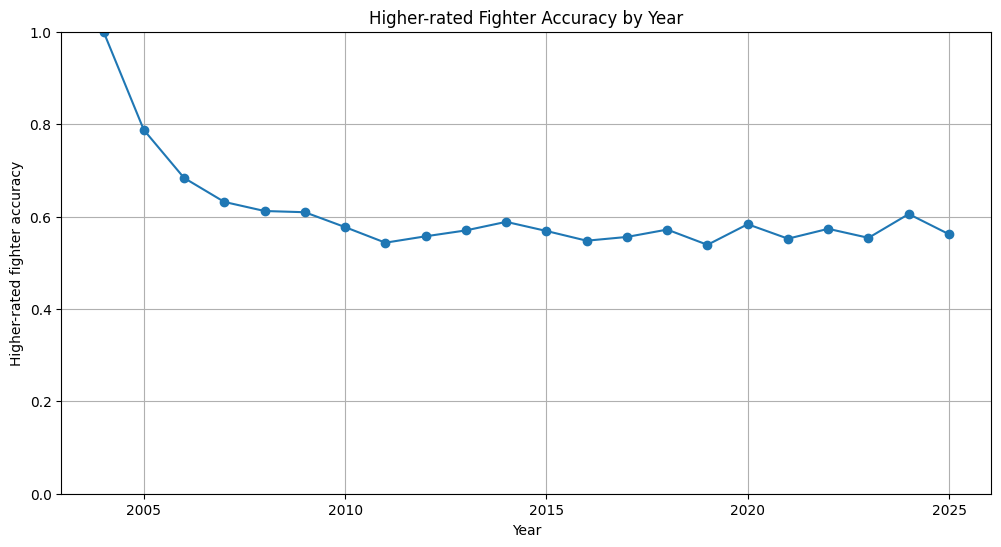

In [34]:
# ----------------------------
# Overall higher-rated fighter accuracy
# ----------------------------
overall_accuracy = ratings_history['higher_correct'].mean()
print(f"Overall higher-rated fighter accuracy: {overall_accuracy:.2%}")

# ----------------------------
# Accuracy after 2010
# ----------------------------
ratings_history['date'] = pd.to_datetime(ratings_history['date'], errors='coerce')
after2010 = ratings_history[ratings_history['date'] >= pd.Timestamp("2010-01-01")]
after2010_accuracy = after2010['higher_correct'].mean()
print(f"Higher-rated fighter accuracy (fights after 2010): {after2010_accuracy:.2%}")

# ----------------------------
# Optional: accuracy by year
# ----------------------------
ratings_history['year'] = ratings_history['date'].dt.year
accuracy_by_year = ratings_history.groupby('year')['higher_correct'].mean()

plt.figure(figsize=(12,6))
accuracy_by_year.plot(marker='o')
plt.ylabel("Higher-rated fighter accuracy")
plt.xlabel("Year")
plt.title("Higher-rated Fighter Accuracy by Year")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

In [37]:
# Convert mu to rating scale
ratings_history['rating_red_pre'] = ratings_history['mu_red_pre'] * 173.7178 + 1500
ratings_history['rating_blue_pre'] = ratings_history['mu_blue_pre'] * 173.7178 + 1500

# Combine into long format
red_ratings = ratings_history[['fighter_red', 'rating_red_pre']].rename(
    columns={'fighter_red': 'fighter', 'rating_red_pre': 'rating'}
)
blue_ratings = ratings_history[['fighter_blue', 'rating_blue_pre']].rename(
    columns={'fighter_blue': 'fighter', 'rating_blue_pre': 'rating'}
)

all_ratings = pd.concat([red_ratings, blue_ratings], ignore_index=True)

# Find peak rating per fighter
peak_ratings = all_ratings.groupby('fighter')['rating'].max().reset_index()

# Sort descending
peak_ratings = peak_ratings.sort_values('rating', ascending=False).reset_index(drop=True)

# Show top 10 fighters by peak rating
print(peak_ratings.head(10))

               fighter        rating
0       Brandon Moreno  20196.898983
1       Jiri Prochazka  13593.930188
2          Ante Delija   9228.678571
3         Michael Page   9189.134035
4     Michael Chandler   8731.164252
5  Alexander Hernandez   8649.003266
6         Grant Dawson   6487.973790
7       Kayla Harrison   6484.437784
8         Da Woon Jung   6032.806132
9    Reinier de Ridder   5789.480633


In [6]:
ratings_history['mu_red_pre'].tail(10)

5020    -2.339141
5021    17.819137
5022    -4.478910
5023     5.232797
5024    29.719271
5025    48.291500
5026     0.000000
5027     4.439174
5028    10.252074
5029    35.073357
Name: mu_red_pre, dtype: float64

In [69]:
ratings_history['p_red_pred'].tail(10)

5020    0.561360
5021    0.813379
5022    0.160221
5023    0.573309
5024    0.980550
5025    0.352938
5026    0.500000
5027    0.734114
5028    0.633237
5029    0.684106
Name: p_red_pred, dtype: float64

In [70]:
ratings_history['p_blue_pred'].tail(10)

KeyError: 'p_blue_pred'

In [9]:
ratings_history.columns

Index(['index', 'date', 'fighter_red', 'fighter_blue', 'outcome', 'mu_red_pre',
       'phi_red_pre', 'sigma_red_pre', 'mu_blue_pre', 'phi_blue_pre',
       'sigma_blue_pre', 'p_red_pred', 'higher_pre', 'higher_correct',
       'rating_red_post', 'rd_red_post', 'sigma_red_post', 'rating_blue_post',
       'rd_blue_post', 'sigma_blue_post', 'year'],
      dtype='object')